# V8: Multi-GNN — Optuna HPO · Balanced Threshold · 5-Fold CV · Feature Importance

**Fixes over V7:**
- **Reduced Grade-1 recall**: class-weight penalty softened to `sqrt(ratio)` ≈ 1.18; per-fold G-mean threshold optimisation replaces fixed 0.5
- **AUC fix**: explicit named-column construction (no brittle positional rename); `try/except` guard for single-class folds
- **5-Fold Stratified CV**: Optuna finds best params once per model×pipeline, then `StratifiedKFold(5)` evaluates generalisation — reports mean ± std across folds
- Final model trained on full train+val, threshold = mean(fold thresholds), evaluated on held-out TCGA test + external CGGA

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

N_TRIALS   = 30    # Optuna TPE trials per model×pipeline
N_FOLDS    = 5     # stratified CV folds
MAX_EPOCHS = 200
PATIENCE   = 20

/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libnvToolsExt.so.1: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 2. Load Data

In [2]:
tcga_df = pd.read_csv('../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))

TCGA: (839, 24)   Grade dist: {0: 487, 1: 352}
CGGA: (286, 24)   Grade dist: {0: 184, 1: 102}


## 3. Splits — 20% held-out test; remaining 80% used for HPO + 5-Fold CV

In [3]:
# Hold out 20% as final test set (never seen during HPO or CV)
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)

# Further split train_val for Optuna HPO warmup (val graph used only in HPO phase)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)

print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))

Train(HPO)=536  Val(HPO)=135  TrainVal(CV)=671  Test=168
Train Grade dist: {0: 311, 1: 225}
Test  Grade dist: {0: 98, 1: 70}


## 4. Graph Construction

In [4]:
_PP_CACHE: dict = {}


def construct_bipartite_heterograph(df: pd.DataFrame) -> HeteroData:
    graph = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[['Age_at_diagnosis']])
    pat_feats = np.hstack([df[['Gender','Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(pat_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx); dst_patients.append(p_idx)

    graph['Gene',    'mutates',    'Patient'].edge_index = torch.tensor([src_genes,    dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'   ].edge_index = torch.tensor([dst_patients, src_genes   ], dtype=torch.long)
    return graph


def get_pp_edges(graph: HeteroData, max_pts: int = 30):
    key = id(graph)
    if key in _PP_CACHE:
        return _PP_CACHE[key]
    ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    gene_ids, pat_ids = ei[0], ei[1]
    n_p = graph['Patient'].x.shape[0]
    all_src, all_dst, all_types = [], [], []
    torch.manual_seed(42)
    for g in range(NUM_GENES):
        mask = (gene_ids == g)
        pts = pat_ids[mask].unique(); n = len(pts)
        if n < 2: continue
        if n > max_pts:
            pts = pts[torch.randperm(n)[:max_pts]]; n = max_pts
        src = pts.repeat_interleave(n); dst = pts.repeat(n)
        valid = (src != dst)
        all_src.append(src[valid]); all_dst.append(dst[valid])
        all_types.append(torch.full((valid.sum(),), g, dtype=torch.long))
    if all_src:
        pp_ei = torch.stack([torch.cat(all_src), torch.cat(all_dst)])
        pp_et = torch.cat(all_types)
    else:
        idx = torch.arange(n_p)
        pp_ei = torch.stack([idx, idx]); pp_et = torch.zeros(n_p, dtype=torch.long)
    _PP_CACHE[key] = (pp_ei, pp_et)
    return pp_ei, pp_et


def to_dev(graph): return graph.to(device)


def clear_pp_cache():
    """Call between CV folds to free stale graph-id entries."""
    _PP_CACHE.clear()

## 5. Build Shared Evaluation Graphs

In [5]:
val_graph  = to_dev(construct_bipartite_heterograph(val_df))
test_graph = to_dev(construct_bipartite_heterograph(test_df))
cgga_graph = to_dev(construct_bipartite_heterograph(cgga_df))

print("Val  graph:", val_graph['Patient'].x.shape[0], "patients")
print("Test graph:", test_graph['Patient'].x.shape[0], "patients")
print("CGGA graph:", cgga_graph['Patient'].x.shape[0], "patients")

Val  graph: 135 patients
Test graph: 168 patients
CGGA graph: 286 patients


## 6. Model Definitions (7 architectures)

| # | Model | Core idea |
|---|-------|-----------|
| 1 | **HeteroGATv2** | Bidirectional GATv2 on Gene-Patient bipartite graph |
| 2 | **MOGAT** | Dual genomic+clinical paths, soft fusion gate |
| 3 | **HyperTMO** | Genes = hyperedges, patients = nodes |
| 4 | **RGCN** | Patient-patient co-mutation graph, 20 gene-typed relations |
| 5 | **VEGN** | Learned per-edge variant-effect weights |
| 6 | **FastHGTConv** | Heterogeneous Graph Transformer |
| 7 | **SGNN** | Chebyshev spectral filters on patient co-mutation adjacency |

In [6]:
# ── 1. HeteroGATv2 ───────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        return self.clf(F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training))

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ── 2. MOGAT ──────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.gate = nn.Linear(hidden_dim * 2, 2); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x)); hgg = F.relu(self.gg(graph['Gene'].x))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        return self.clf(g[:, :1] * hpg + g[:, 1:] * hpc)


# ── 3. HyperTMO ───────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=3, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)        # projects hyperedge attrs
        self.hc1 = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                   heads=num_heads, dropout=dropout, concat=False)
        self.hc2 = HypergraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        ei = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)   # [patient, gene]
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp, hei) + s))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN ───────────────────────────────────────────────────────
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.rc1 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, pp_et = get_pp_edges(graph)
        pp_ei = pp_ei.to(xp.device); pp_et = pp_et.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = F.relu(self.rc1(h, pp_ei, pp_et))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── 5. VEGN ───────────────────────────────────────────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.ve = nn.Sequential(nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp, hg), e_p2g)
        hp2 = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        return self.clf(F.dropout(hp2, self.dr, training=self.training))


# ── 6. FastHGTConv ────────────────────────────────────────────────
_HGT_META = (['Patient','Gene'],
              [('Gene','mutates','Patient'),('Patient','mutated_by','Gene')])

class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.hgt1 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.hgt2 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k, v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 7. SGNN ───────────────────────────────────────────────────────
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, K=3, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.c1 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, _ = get_pp_edges(graph); pp_ei = pp_ei.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = self.bn1(F.relu(self.c1(h, pp_ei)))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── Registry ──────────────────────────────────────────────────────
MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 3}),
    ('RGCN',        RGCNModel,    {'in_channels': 3, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {}),
    ('SGNN',        SGNNModel,    {'in_channels': 3}),
]
print(f"Registered {len(MODEL_REGISTRY)} models:", [n for n,_,_ in MODEL_REGISTRY])

Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


## 7. Focal Loss + Softened Class Weights

**Fix**: penalty changed from `ratio` (≈1.38) to `sqrt(ratio)` (≈1.18).  
The FocalLoss `gamma=2` already down-weights easy examples; stacking a high class penalty over-corrects and inflates Grade-1 recall. Softening to square-root keeps a mild correction without making the decision boundary too aggressive toward Grade-1.

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()

counts  = train_df['Grade'].value_counts()
# ── FIX: soften penalty from ratio → sqrt(ratio) ─────────────────
penalty = float(np.sqrt(counts.max() / counts.min()))   # was counts.max()/counts.min()
cw      = torch.tensor([1.0, penalty], dtype=torch.float).to(device)
criterion = FocalLoss(alpha=1, gamma=2, weight=cw)
print(f"Class weights: [1.0, {penalty:.4f}]  (sqrt-penalty; was {counts.max()/counts.min():.4f})")

Class weights: [1.0, 1.1757]  (sqrt-penalty; was 1.3822)


## 8. Threshold Optimisation + Evaluation Helpers

**Fix**: `find_optimal_threshold()` searches `[0.30, 0.75]` for the threshold maximising **G-mean = √(recall₀ × recall₁)**. G-mean is maximised when both recalls are balanced, so Grade-1 recall can no longer climb arbitrarily high at Grade-0's expense.

**AUC fix**: `compute_metrics()` uses explicit `try/except` around `roc_auc_score` and returns `nan` for degenerate folds rather than crashing.

In [8]:
# ── FIX: G-mean threshold search ─────────────────────────────────
def find_optimal_threshold(probs: np.ndarray, labels: np.ndarray,
                            low: float = 0.30, high: float = 0.75,
                            step: float = 0.01) -> float:
    """Return the decision threshold in [low, high] that maximises
    G-mean = sqrt(sensitivity_0 * sensitivity_1).
    Falls back to 0.5 if no positive G-mean is found."""
    best_th, best_gm = 0.5, -1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1 = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0 = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm = np.sqrt(r0 * r1)
        if gm > best_gm:
            best_gm = gm; best_th = float(th)
    return best_th


def evaluate_model(model, graph, threshold: float = 0.5):
    """Return (preds, probs, labels) using a calibrated threshold."""
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds: np.ndarray, probs: np.ndarray,
                     labels: np.ndarray) -> dict:
    """AUC fix: explicit try/except; also report per-class recall."""
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')   # single-class fold guard
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),       # Grade-1 recall
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }


# Storage containers
all_results  = []    # final test/CGGA results
cv_results   = []    # per-fold CV results
all_models   = {}    # {(model_name, pipeline): trained model}
all_studies  = {}    # {(model_name, pipeline): optuna study}
all_params   = {}    # {(model_name, pipeline): best_params}
all_thresholds = {}  # {(model_name, pipeline): threshold}
PIPELINES    = ['No Balancing', 'SMOTE', 'CTGAN']

## 9. Unified Training Function

In [9]:
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Train model; return (best_val_auc, best_state, history)."""
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = criterion(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

## 10. Optuna HPO (warm-up on train_df / val_df)

In [10]:
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    """Bayesian HPO; return (best_params, best_state, study)."""

    def objective(trial):
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_and_evaluate(train_graph, val_graph, params, ModelClass, fixed_kw)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_and_evaluate(train_graph, val_graph, bp, ModelClass, fixed_kw)
    return bp, best_state, study

## 11. 5-Fold Stratified Cross-Validation

Uses the **fixed best params** found by Optuna.  Each fold: augment training portion → build graph → train → find G-mean threshold on val → evaluate.  
Reports mean ± std across folds for AUC, Accuracy, Precision, Recall (Grade-1 & Grade-0), F1, Threshold.

In [11]:
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True)
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    return pd.concat([fold_train_df, extra], ignore_index=True)


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name):
    """Run StratifiedKFold(5) with fixed best_params.
    Returns DataFrame of per-fold metrics."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        # Apply augmentation to training portion only
        if pipeline_name == 'SMOTE':
            fold_tr = apply_smote(fold_tr)
        elif pipeline_name == 'CTGAN':
            fold_tr = apply_ctgan(fold_tr)

        clear_pp_cache()    # prevent stale cache entries across folds
        tr_g = to_dev(construct_bipartite_heterograph(fold_tr))
        vl_g = to_dev(construct_bipartite_heterograph(fold_vl))

        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw)

        # Build model for this fold
        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        # ── FIX: calibrated threshold per fold ────────────────────
        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    clear_pp_cache()
    return pd.DataFrame(fold_records)

## 12. Pipeline Runner (shared by all 3 pipelines)

In [12]:
def run_pipeline(pipeline_name, train_graph_hpo, augment_fn=None):
    """
    For each model in MODEL_REGISTRY:
      1. Optuna HPO on train_df/val_df (or augmented version)
      2. 5-Fold CV on train_val_df with best params
      3. Final model on full train_val (or augmented), calibrated threshold
      4. Evaluate on TCGA test + CGGA
    """
    print(f"\n{'='*65}")
    print(f"PIPELINE: {pipeline_name}")
    print(f"{'='*65}")

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f"\n  ── {mname} ──")

        # ── Step 1: Optuna HPO ────────────────────────────────────
        bp, hpo_state, study = run_optuna(
            train_graph_hpo, val_graph, MCls, fkw,
            label=f"{mname}/{pipeline_name}")
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname, pipeline_name)]  = bp

        # ── Step 2: 5-Fold CV ─────────────────────────────────────
        print(f"  5-Fold CV with best params:")
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw, pipeline_name, mname)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f"    {col:12s}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}")

        # ── Step 3: Final model on full train_val ─────────────────
        if augment_fn is not None:
            aug_df = augment_fn(train_val_df.copy())
        else:
            aug_df = train_val_df
        clear_pp_cache()
        full_tr_graph = to_dev(construct_bipartite_heterograph(aug_df))

        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        # Threshold = mean of CV fold thresholds
        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f"  Final threshold (mean of CV folds) = {th:.3f}")

        # ── Step 4: Evaluate on test / CGGA ───────────────────────
        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f"  TCGA-Test  AUC={mt['auc']:.4f} R1={mt['recall']:.3f} R0={mt['recall_0']:.3f} F1={mt['f1']:.4f}")
        print(f"  CGGA       AUC={mc_['auc']:.4f} R1={mc_['recall']:.3f} R0={mc_['recall_0']:.3f} F1={mc_['f1']:.4f}")

        for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc_, pbc, lbc)]:
            rec = {'Model': mname, 'Pipeline': pipeline_name, 'Dataset': ds,
                   'threshold': th, 'probs': p, 'labels': l}
            rec.update(m)
            all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model
        clear_pp_cache()

    print(f"\n[{pipeline_name}] Done.")

## 13. Pipeline A — No Balancing

In [13]:
train_nb_graph = to_dev(construct_bipartite_heterograph(train_df))
run_pipeline('No Balancing', train_graph_hpo=train_nb_graph, augment_fn=None)


PIPELINE: No Balancing

  ── HeteroGATv2 ──


Best trial: 14. Best value: 0.939946: 100%|██████████| 30/30 [00:25<00:00,  1.20it/s]


  [HeteroGATv2/No Balancing] Best AUC=0.9399  params={'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.15000000000000002, 'lr': 0.0037927492630521783, 'weight_decay': 0.00018000554787310762}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9154 R1=0.930 R0=0.872 F1=0.8833 th=0.43
    Fold 2/5 | AUC=0.9228 R1=0.875 R0=0.885 F1=0.8596 th=0.52
    Fold 3/5 | AUC=0.8919 R1=0.929 R0=0.782 F1=0.8320 th=0.36
    Fold 4/5 | AUC=0.9471 R1=0.911 R0=0.910 F1=0.8947 th=0.56
    Fold 5/5 | AUC=0.9146 R1=0.947 R0=0.779 F1=0.8438 th=0.42
    auc         : 0.9184 ± 0.0198
    accuracy    : 0.8763 ± 0.0288
    precision   : 0.8159 ± 0.0558
    recall      : 0.9183 ± 0.0275
    recall_0    : 0.8456 ± 0.0609
    f1          : 0.8627 ± 0.0263
    threshold   : 0.4580 ± 0.0807
  Final threshold (mean of CV folds) = 0.458
  TCGA-Test  AUC=0.9223 R1=0.929 R0=0.796 F1=0.8387
  CGGA       AUC=0.7616 R1=0.843 R0=0.462 F1=0.5993

  ── MOGAT ──


Best trial: 8. Best value: 0.943995: 100%|██████████| 30/30 [00:24<00:00,  1.21it/s]


  [MOGAT/No Balancing] Best AUC=0.9440  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.2, 'lr': 0.0059487468132197715, 'weight_decay': 8.798929749689021e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9082 R1=0.930 R0=0.846 F1=0.8689 th=0.43
    Fold 2/5 | AUC=0.9299 R1=0.875 R0=0.885 F1=0.8596 th=0.50
    Fold 3/5 | AUC=0.9071 R1=0.893 R0=0.859 F1=0.8547 th=0.50
    Fold 4/5 | AUC=0.9462 R1=0.911 R0=0.885 F1=0.8793 th=0.56
    Fold 5/5 | AUC=0.9269 R1=0.947 R0=0.805 F1=0.8571 th=0.43
    auc         : 0.9237 ± 0.0164
    accuracy    : 0.8793 ± 0.0111
    precision   : 0.8225 ± 0.0269
    recall      : 0.9112 ± 0.0287
    recall_0    : 0.8559 ± 0.0329
    f1          : 0.8639 ± 0.0101
    threshold   : 0.4840 ± 0.0550
  Final threshold (mean of CV folds) = 0.484
  TCGA-Test  AUC=0.9171 R1=0.929 R0=0.816 F1=0.8497
  CGGA       AUC=0.7263 R1=0.804 R0=0.511 F1=0.5985

  ── HyperTMO ──


...

  [VEGN/No Balancing] Best AUC=0.9433  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.009898370891108491, 'weight_decay': 0.00014588587199599302}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9303 R1=0.912 R0=0.885 F1=0.8814 th=0.48
    Fold 2/5 | AUC=0.9160 R1=0.893 R0=0.897 F1=0.8772 th=0.45
    Fold 3/5 | AUC=0.8949 R1=0.839 R0=0.859 F1=0.8246 th=0.54
    Fold 4/5 | AUC=0.9446 R1=0.929 R0=0.859 F1=0.8739 th=0.51
    Fold 5/5 | AUC=0.9225 R1=0.965 R0=0.792 F1=0.8594 th=0.46
    auc         : 0.9217 ± 0.0184
    accuracy    : 0.8793 ± 0.0202
    precision   : 0.8250 ± 0.0349
    recall      : 0.9076 ± 0.0465
    recall_0    : 0.8584 ± 0.0406
    f1          : 0.8633 ± 0.0232
    threshold   : 0.4880 ± 0.0370
  Final threshold (mean of CV folds) = 0.488
  TCGA-Test  AUC=0.9239 R1=0.886 R0=0.816 F1=0.8267
  CGGA       AUC=0.7633 R1=0.804 R0=0.603 F1=0.6381

  ── FastHGTConv ──


Best trial: 25. Best value: 0.94152: 100%|██████████| 30/30 [00:48<00:00,  1.62s/it] 


  [FastHGTConv/No Balancing] Best AUC=0.9415  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.004743726842108359, 'weight_decay': 0.00041802476287718636}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9327 R1=0.895 R0=0.897 F1=0.8793 th=0.49
    Fold 2/5 | AUC=0.9251 R1=0.875 R0=0.910 F1=0.8750 th=0.46
    Fold 3/5 | AUC=0.9020 R1=0.893 R0=0.872 F1=0.8621 th=0.47
    Fold 4/5 | AUC=0.9554 R1=0.875 R0=0.936 F1=0.8909 th=0.57
    Fold 5/5 | AUC=0.9228 R1=0.947 R0=0.805 F1=0.8571 th=0.42
    auc         : 0.9276 ± 0.0192
    accuracy    : 0.8897 ± 0.0171
    precision   : 0.8526 ± 0.0472
    recall      : 0.8970 ± 0.0297
    recall_0    : 0.8841 ± 0.0498
    f1          : 0.8729 ± 0.0136
    threshold   : 0.4820 ± 0.0554
  Final threshold (mean of CV folds) = 0.482
  TCGA-Test  AUC=0.9034 R1=0.900 R0=0.806 F1=0.8289
  CGGA       AUC=0.6665 R1=0.745 R0=0.538 F1=0.5779

  ── SGNN ──


Best trial: 15. Best value: 0.909807: 100%|██████████| 30/30 [00:20<00:00,  1.48it/s]


  [SGNN/No Balancing] Best AUC=0.9098  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.000716066911301265, 'weight_decay': 4.632509168292423e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8225 R1=0.719 R0=0.782 F1=0.7130 th=0.53
    Fold 2/5 | AUC=0.8965 R1=0.821 R0=0.859 F1=0.8142 th=0.54
    Fold 3/5 | AUC=0.8487 R1=0.839 R0=0.782 F1=0.7833 th=0.55
    Fold 4/5 | AUC=0.8887 R1=0.875 R0=0.846 F1=0.8376 th=0.46
    Fold 5/5 | AUC=0.8786 R1=0.877 R0=0.779 F1=0.8065 th=0.53
    auc         : 0.8670 ± 0.0308
    accuracy    : 0.8168 ± 0.0397
    precision   : 0.7596 ± 0.0440
    recall      : 0.8264 ± 0.0644
    recall_0    : 0.8097 ± 0.0394
    f1          : 0.7909 ± 0.0477
    threshold   : 0.5220 ± 0.0356
  Final threshold (mean of CV folds) = 0.522
  TCGA-Test  AUC=0.8560 R1=0.729 R0=0.806 F1=0.7286
  CGGA       AUC=0.6848 R1=0.912 R0=0.310 F1=0.5776

[No Balancing] Done.


## 14. Pipeline B — SMOTE

In [14]:
feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
cat_idx   = [i for i,c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]
smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols); train_smote_df['Grade'] = yr
for c in gene_columns: train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE HPO graph class dist:\n", train_smote_df['Grade'].value_counts())

train_sm_graph = to_dev(construct_bipartite_heterograph(train_smote_df))
run_pipeline('SMOTE', train_graph_hpo=train_sm_graph, augment_fn=apply_smote)

SMOTE HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: SMOTE

  ── HeteroGATv2 ──


Best trial: 29. Best value: 0.931399: 100%|██████████| 30/30 [00:21<00:00,  1.40it/s]


  [HeteroGATv2/SMOTE] Best AUC=0.9314  params={'hidden_dim': 64, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.0074497312398989855, 'weight_decay': 0.00019445738712331172}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9157 R1=0.930 R0=0.885 F1=0.8908 th=0.48
    Fold 2/5 | AUC=0.9103 R1=0.875 R0=0.872 F1=0.8522 th=0.50
    Fold 3/5 | AUC=0.9038 R1=0.893 R0=0.821 F1=0.8333 th=0.52
    Fold 4/5 | AUC=0.9499 R1=0.893 R0=0.897 F1=0.8772 th=0.58
    Fold 5/5 | AUC=0.9310 R1=0.930 R0=0.831 F1=0.8618 th=0.49
    auc         : 0.9221 ± 0.0185
    accuracy    : 0.8792 ± 0.0209
    precision   : 0.8263 ± 0.0342
    recall      : 0.9041 ± 0.0246
    recall_0    : 0.8611 ± 0.0337
    f1          : 0.8630 ± 0.0222
    threshold   : 0.5140 ± 0.0397
  Final threshold (mean of CV folds) = 0.514
  TCGA-Test  AUC=0.8904 R1=0.814 R0=0.837 F1=0.7972
  CGGA       AUC=0.7090 R1=0.706 R0=0.582 F1=0.5737

  ── MOGAT ──


Best trial: 23. Best value: 0.935673: 100%|██████████| 30/30 [00:17<00:00,  1.67it/s]


  [MOGAT/SMOTE] Best AUC=0.9357  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.003906203701366751, 'weight_decay': 0.0002063697301510386}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9139 R1=0.930 R0=0.872 F1=0.8833 th=0.50
    Fold 2/5 | AUC=0.9139 R1=0.875 R0=0.910 F1=0.8750 th=0.56
    Fold 3/5 | AUC=0.9032 R1=0.839 R0=0.885 F1=0.8393 th=0.59
    Fold 4/5 | AUC=0.9446 R1=0.929 R0=0.872 F1=0.8814 th=0.58
    Fold 5/5 | AUC=0.9330 R1=0.947 R0=0.844 F1=0.8780 th=0.48
    auc         : 0.9217 ± 0.0167
    accuracy    : 0.8882 ± 0.0130
    precision   : 0.8425 ± 0.0205
    recall      : 0.9040 ± 0.0452
    recall_0    : 0.8765 ± 0.0240
    f1          : 0.8714 ± 0.0182
    threshold   : 0.5420 ± 0.0492
  Final threshold (mean of CV folds) = 0.542
  TCGA-Test  AUC=0.9217 R1=0.857 R0=0.867 F1=0.8392
  CGGA       AUC=0.7359 R1=0.745 R0=0.598 F1=0.6032

  ── HyperTMO ──


...

  [VEGN/SMOTE] Best AUC=0.9388  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.006530389878554476, 'weight_decay': 9.9335137650869e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9082 R1=0.912 R0=0.872 F1=0.8739 th=0.51
    Fold 2/5 | AUC=0.9144 R1=0.929 R0=0.833 F1=0.8595 th=0.45
    Fold 3/5 | AUC=0.8947 R1=0.929 R0=0.795 F1=0.8387 th=0.40
    Fold 4/5 | AUC=0.9494 R1=0.946 R0=0.885 F1=0.8983 th=0.53
    Fold 5/5 | AUC=0.9152 R1=0.965 R0=0.805 F1=0.8661 th=0.47
    auc         : 0.9164 ± 0.0202
    accuracy    : 0.8793 ± 0.0221
    precision   : 0.8088 ± 0.0373
    recall      : 0.9362 ± 0.0201
    recall_0    : 0.8380 ± 0.0396
    f1          : 0.8673 ± 0.0217
    threshold   : 0.4720 ± 0.0512
  Final threshold (mean of CV folds) = 0.472
  TCGA-Test  AUC=0.9087 R1=0.929 R0=0.745 F1=0.8125
  CGGA       AUC=0.7383 R1=0.784 R0=0.598 F1=0.6250

  ── FastHGTConv ──


Best trial: 3. Best value: 0.936572: 100%|██████████| 30/30 [00:53<00:00,  1.78s/it]


  [FastHGTConv/SMOTE] Best AUC=0.9366  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.0023359635026261607, 'weight_decay': 7.591104805282687e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9256 R1=0.895 R0=0.885 F1=0.8718 th=0.51
    Fold 2/5 | AUC=0.9171 R1=0.857 R0=0.923 F1=0.8727 th=0.53
    Fold 3/5 | AUC=0.9132 R1=0.857 R0=0.846 F1=0.8276 th=0.56
    Fold 4/5 | AUC=0.9405 R1=0.946 R0=0.846 F1=0.8760 th=0.49
    Fold 5/5 | AUC=0.9271 R1=0.982 R0=0.792 F1=0.8682 th=0.49
    auc         : 0.9247 ± 0.0105
    accuracy    : 0.8793 ± 0.0179
    precision   : 0.8264 ± 0.0437
    recall      : 0.9076 ± 0.0556
    recall_0    : 0.8584 ± 0.0489
    f1          : 0.8633 ± 0.0201
    threshold   : 0.5160 ± 0.0297
  Final threshold (mean of CV folds) = 0.516
  TCGA-Test  AUC=0.8535 R1=0.800 R0=0.837 F1=0.7887
  CGGA       AUC=0.6581 R1=0.627 R0=0.647 F1=0.5541

  ── SGNN ──


Best trial: 19. Best value: 0.904408: 100%|██████████| 30/30 [00:15<00:00,  1.97it/s]


  [SGNN/SMOTE] Best AUC=0.9044  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.002113655465531594, 'weight_decay': 0.00044816216043863015}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8552 R1=0.754 R0=0.795 F1=0.7414 th=0.51
    Fold 2/5 | AUC=0.9041 R1=0.929 R0=0.782 F1=0.8320 th=0.45
    Fold 3/5 | AUC=0.8553 R1=0.821 R0=0.833 F1=0.8000 th=0.61
    Fold 4/5 | AUC=0.8929 R1=0.911 R0=0.821 F1=0.8430 th=0.49
    Fold 5/5 | AUC=0.8827 R1=0.825 R0=0.844 F1=0.8103 th=0.57
    auc         : 0.8780 ± 0.0221
    accuracy    : 0.8287 ± 0.0305
    precision   : 0.7687 ± 0.0273
    recall      : 0.8479 ± 0.0715
    recall_0    : 0.8150 ± 0.0260
    f1          : 0.8053 ± 0.0396
    threshold   : 0.5260 ± 0.0639
  Final threshold (mean of CV folds) = 0.526
  TCGA-Test  AUC=0.8618 R1=0.914 R0=0.684 F1=0.7758
  CGGA       AUC=0.5814 R1=0.353 R0=0.674 F1=0.3636

[SMOTE] Done.


## 15. Pipeline C — CTGAN

In [17]:
meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True)
synth.fit(train_df)
cond   = Condition(num_rows=n_need, column_values={'Grade': int(min_c)})
syn_s  = synth.sample_from_conditions(conditions=[cond])
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN HPO graph class dist:\n", train_ctgan_df['Grade'].value_counts())

train_ct_graph = to_dev(construct_bipartite_heterograph(train_ctgan_df))
run_pipeline('CTGAN', train_graph_hpo=train_ct_graph, augment_fn=apply_ctgan)

print("\n✓ All 21 model × pipeline combinations complete.")

Generating 86 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 435.72it/s]


CTGAN HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: CTGAN

  ── HeteroGATv2 ──


Best trial: 15. Best value: 0.940621: 100%|██████████| 30/30 [00:23<00:00,  1.28it/s]


  [HeteroGATv2/CTGAN] Best AUC=0.9406  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.009370163515284018, 'weight_decay': 9.133610788630916e-05}
  5-Fold CV with best params:


...

    Fold 4/5 | AUC=0.8638 R1=0.857 R0=0.846 F1=0.8276 th=0.49


Sampling conditions: 100%|██████████| 87/87 [00:00<00:00, 554.42it/s]


    Fold 5/5 | AUC=0.8988 R1=0.947 R0=0.792 F1=0.8504 th=0.41
    auc         : 0.8626 ± 0.0285
    accuracy    : 0.8212 ± 0.0475
    precision   : 0.7454 ± 0.0645
    recall      : 0.8830 ± 0.0476
    recall_0    : 0.7764 ± 0.0755
    f1          : 0.8069 ± 0.0451
    threshold   : 0.4580 ± 0.0487


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 333.98it/s]


  Final threshold (mean of CV folds) = 0.458
  TCGA-Test  AUC=0.8510 R1=0.943 R0=0.480 F1=0.7059
  CGGA       AUC=0.6003 R1=0.627 R0=0.478 F1=0.4885

[CTGAN] Done.

✓ All 21 model × pipeline combinations complete.


## 16. 5-Fold CV Summary Table

In [ ]:
cv_all = pd.concat(cv_results, ignore_index=True)

# Mean ± std per model × pipeline
cv_summary = (cv_all.groupby(['Model','Pipeline'])
              [['auc','accuracy','precision','recall','recall_0','f1','threshold']]
              .agg(['mean','std'])
              .round(4))
print("\n5-FOLD CV SUMMARY (mean ± std)")
print("="*90)
print(cv_summary.to_string())

# Compact display: mean(std) format
cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f}±{g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f}±{g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f}±{g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f}±{g['f1'].std():.4f}",
        'Threshold': f"{g['threshold'].mean():.3f}±{g['threshold'].std():.3f}",
    })
).reset_index()
print("\nCompact CV Table:")
print(cv_compact.to_string(index=False))


5-FOLD CV SUMMARY (mean ± std)
                             auc         accuracy         precision          recall         recall_0              f1         threshold        
                            mean     std     mean     std      mean     std    mean     std     mean     std    mean     std      mean     std
Model       Pipeline                                                                                                                          
FastHGTConv CTGAN         0.9274  0.0144   0.8748  0.0145    0.8126  0.0299  0.9147  0.0238   0.8457  0.0332  0.8601  0.0138     0.544  0.0573
            No Balancing  0.9276  0.0192   0.8897  0.0171    0.8526  0.0472  0.8970  0.0297   0.8841  0.0498  0.8729  0.0136     0.482  0.0554
            SMOTE         0.9247  0.0105   0.8793  0.0179    0.8264  0.0437  0.9076  0.0556   0.8584  0.0489  0.8633  0.0201     0.516  0.0297
HeteroGATv2 CTGAN         0.9110  0.0199   0.8681  0.0260    0.8076  0.0439  0.9060  0.0347   0.8405  0.0497  

## 17. Final Results Table (TCGA Test + CGGA)

**AUC fix**: columns built explicitly by name — no brittle positional assignment.

In [19]:
# ── FIX: explicit named-column construction (no brittle positional rename) ──
results_df = pd.DataFrame([
    {
        'Model':     r['Model'],
        'Pipeline':  r['Pipeline'],
        'Dataset':   r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC':       round(r['auc'], 4),
        'Accuracy':  round(r['accuracy'], 4),
        'Precision': round(r['precision'], 4),
        'Recall_1':  round(r['recall'], 4),       # Grade-1 recall (was inflated)
        'Recall_0':  round(r['recall_0'], 4),      # Grade-0 recall
        'F1':        round(r['f1'], 4),
    }
    for r in all_results
])

print("\n" + "="*110)
print("FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS")
print("="*110)
print(results_df.to_string(index=False))

for ds in ['TCGA Test', 'CGGA']:
    sub = results_df[results_df.Dataset == ds]
    print(f"\nTop-5 by AUC on {ds}:")
    print(sub.sort_values('AUC', ascending=False)
             .head(5)[['Model','Pipeline','AUC','Recall_1','Recall_0','F1']]
             .to_string(index=False))


FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS
      Model     Pipeline   Dataset  Threshold    AUC  Accuracy  Precision  Recall_1  Recall_0     F1
HeteroGATv2 No Balancing TCGA Test      0.458 0.9223    0.8512     0.7647    0.9286    0.7959 0.8387
HeteroGATv2 No Balancing      CGGA      0.458 0.7616    0.5979     0.4649    0.8431    0.4620 0.5993
      MOGAT No Balancing TCGA Test      0.484 0.9171    0.8631     0.7831    0.9286    0.8163 0.8497
      MOGAT No Balancing      CGGA      0.484 0.7263    0.6154     0.4767    0.8039    0.5109 0.5985
   HyperTMO No Balancing TCGA Test      0.494 0.8297    0.7440     0.6753    0.7429    0.7449 0.7075
   HyperTMO No Balancing      CGGA      0.494 0.7154    0.6469     0.5038    0.6569    0.6413 0.5702
       RGCN No Balancing TCGA Test      0.464 0.8789    0.7440     0.6337    0.9143    0.6224 0.7485
       RGCN No Balancing      CGGA      0.464 0.6787    0.5490     0.4237    0.7353    0.4457 0.5376
       VEGN No Balancing TCGA Test    

## 18. AUC Heatmaps

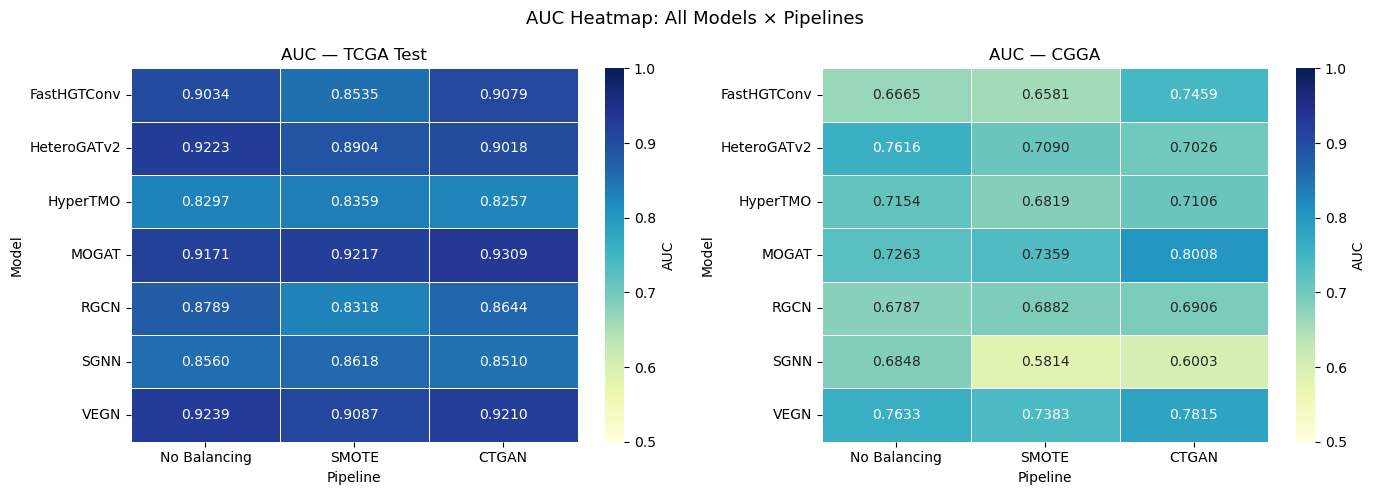

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # pivot_table with aggfunc='mean' safely handles any duplicate rows
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline',
                          values='AUC', aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUC'})
    ax.set_title(f'AUC — {ds}', fontsize=12)
    ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout()
plt.savefig('V8_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Recall Heatmaps — Grade-1 and Grade-0 (TCGA Test)

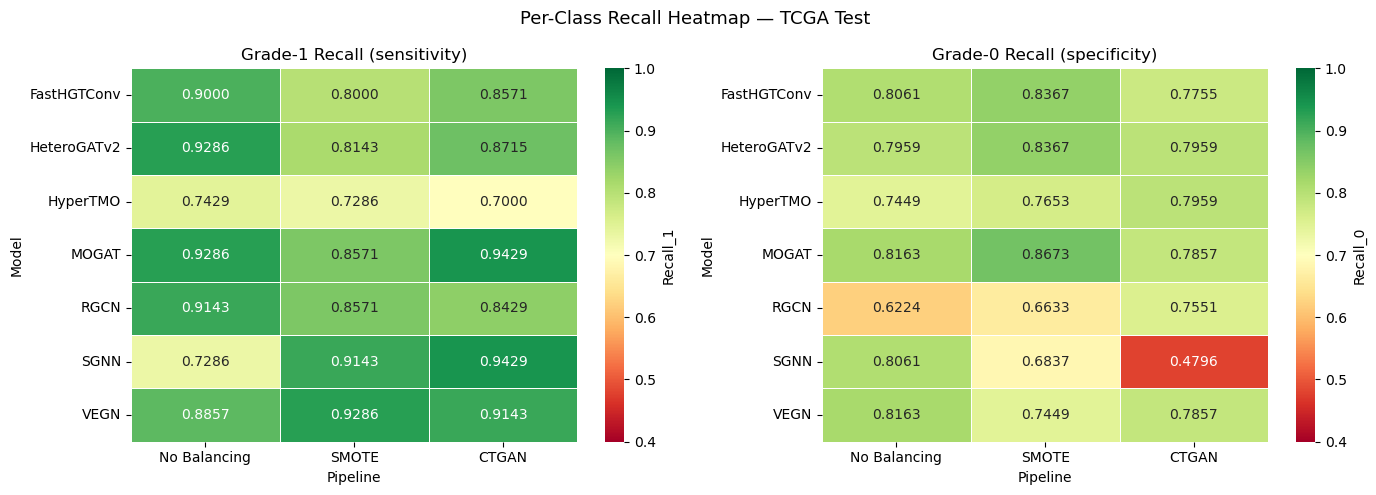

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
        (axes[0], 'Recall_1', 'Grade-1 Recall (sensitivity)'),
        (axes[1], 'Recall_0', 'Grade-0 Recall (specificity)')]:
    pivot = (results_df[results_df.Dataset == 'TCGA Test']
             .pivot_table(index='Model', columns='Pipeline',
                          values=col, aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0,
                cbar_kws={'label': col})
    ax.set_title(title); ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('Per-Class Recall Heatmap — TCGA Test', fontsize=13)
plt.tight_layout()
plt.savefig('V8_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. 5-Fold CV Box Plots

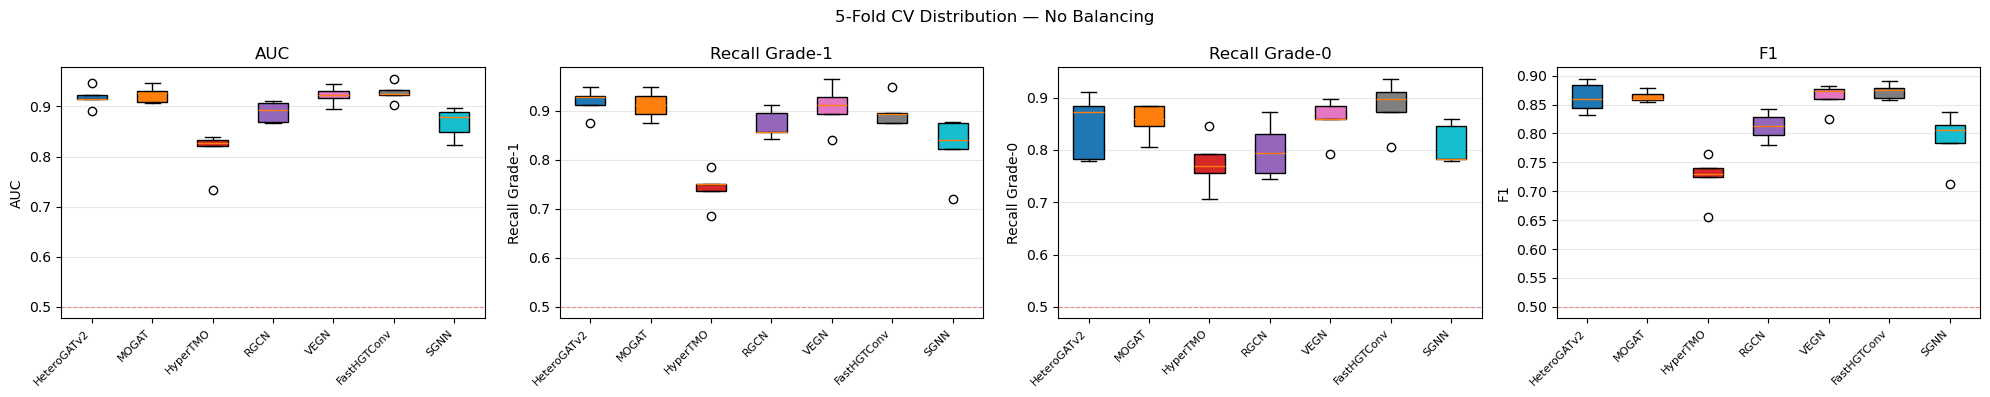

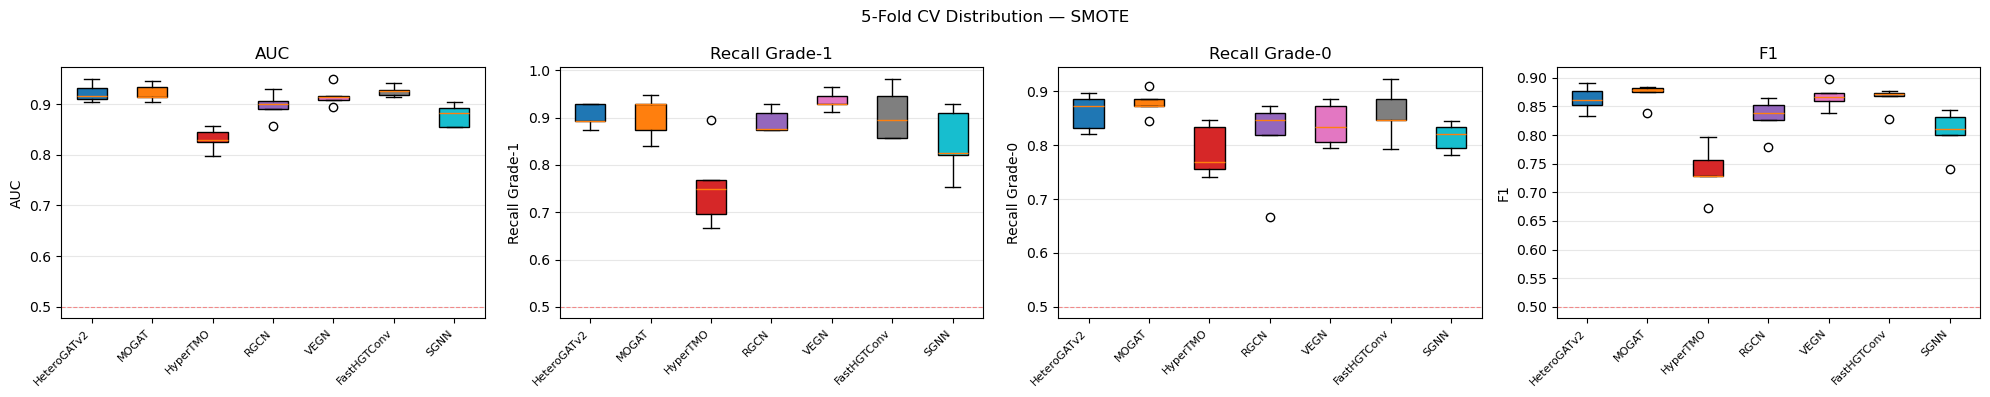

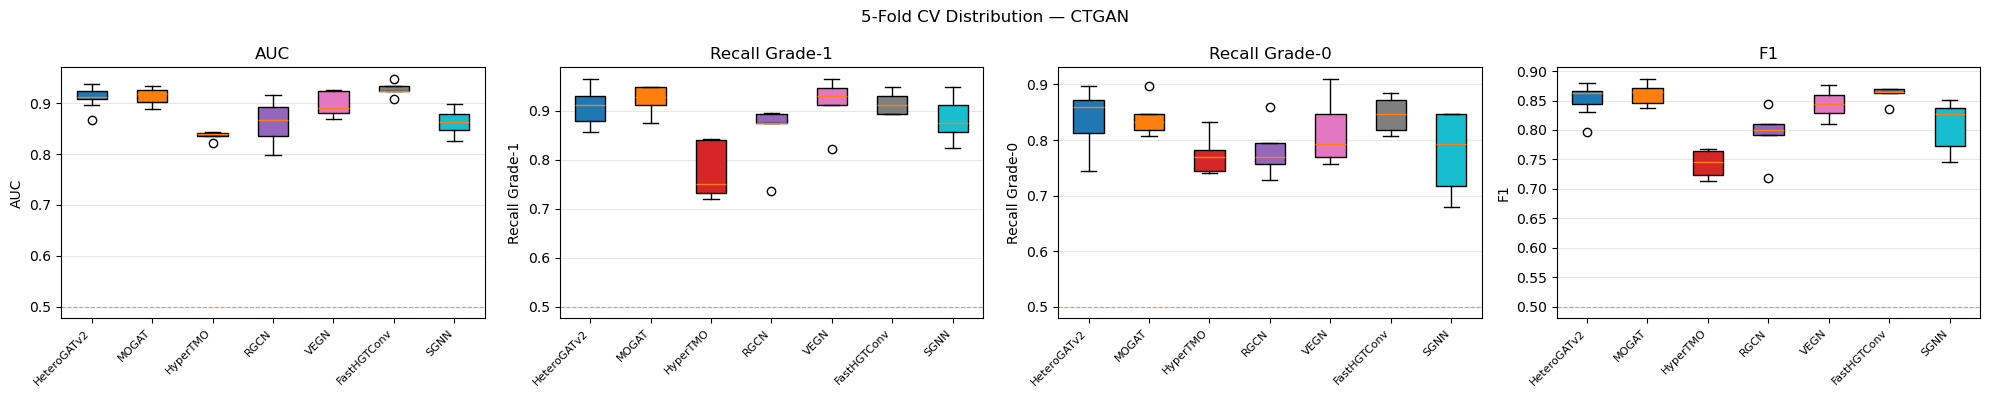

In [24]:
metrics_cv = ['auc', 'recall', 'recall_0', 'f1']
labels_cv  = ['AUC', 'Recall Grade-1', 'Recall Grade-0', 'F1']
model_names = [n for n, _, _ in MODEL_REGISTRY]

for pipe in PIPELINES:
    sub = cv_all[cv_all.Pipeline == pipe]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, met, lab in zip(axes, metrics_cv, labels_cv):
        data = [sub[sub.Model == m][met].values for m in model_names]
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
        for patch, col in zip(bp['boxes'], colors):
            patch.set_facecolor(col)
        ax.set_xticks(range(1, len(model_names)+1))
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(lab); ax.set_title(lab); ax.grid(axis='y', alpha=0.3)
        ax.axhline(0.5, color='red', ls='--', alpha=0.4, lw=0.8)
    plt.suptitle(f'5-Fold CV Distribution — {pipe}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V8_cv_boxplot_{pipe.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 21. ROC Curve Grid

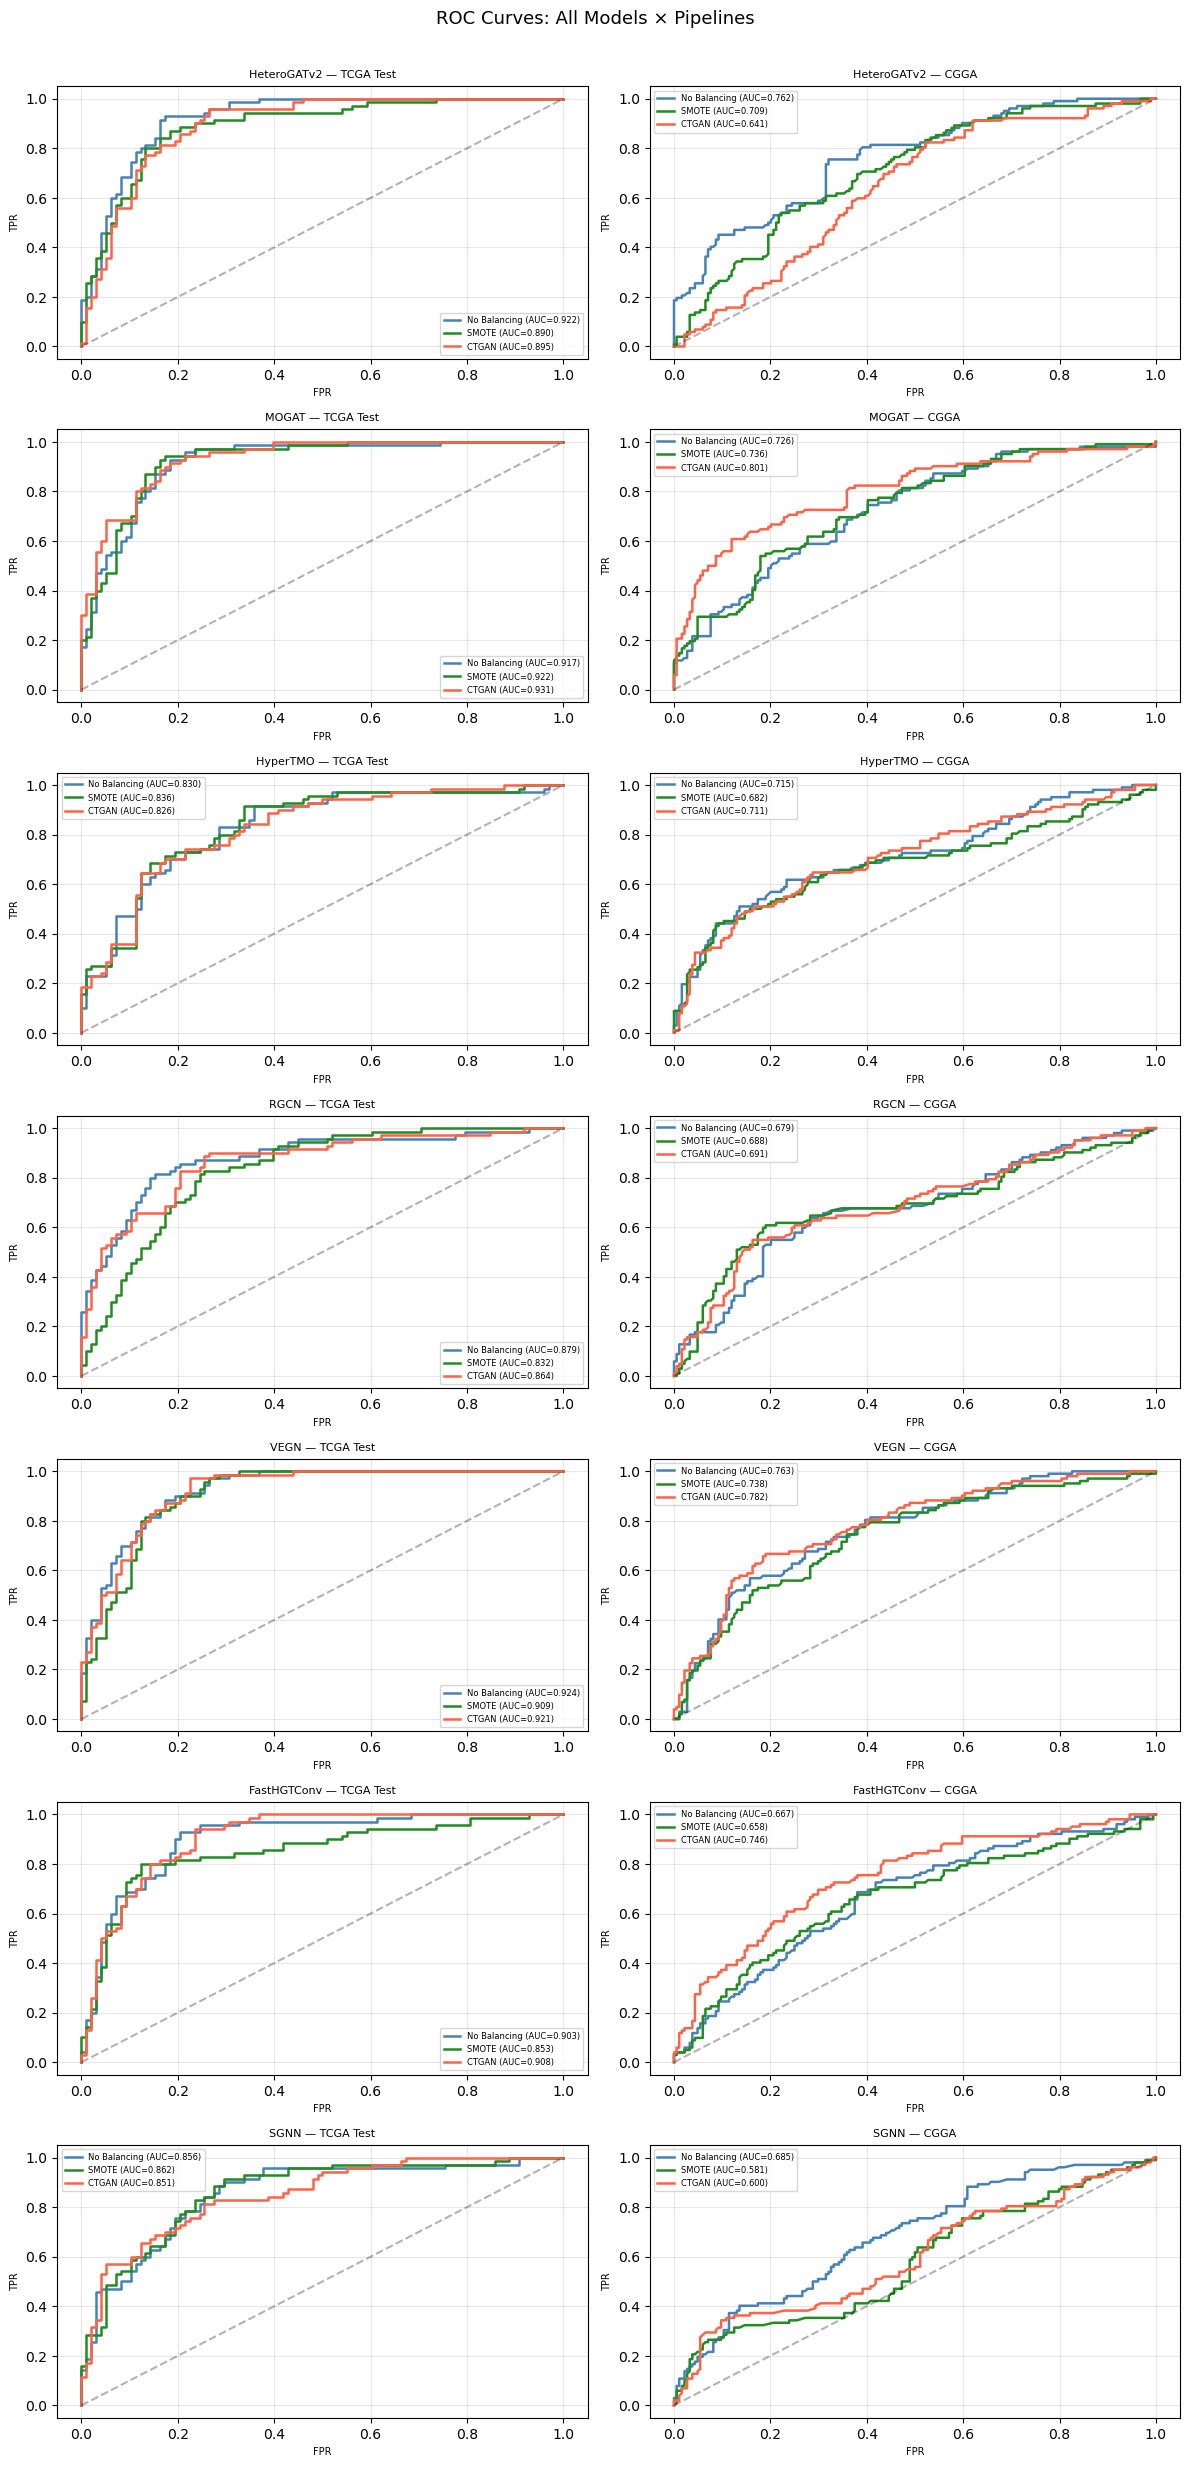

In [25]:
results_full = pd.DataFrame(all_results)
pipe_colors  = {'No Balancing':'steelblue', 'SMOTE':'forestgreen', 'CTGAN':'tomato'}

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('V8_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Confusion Matrices

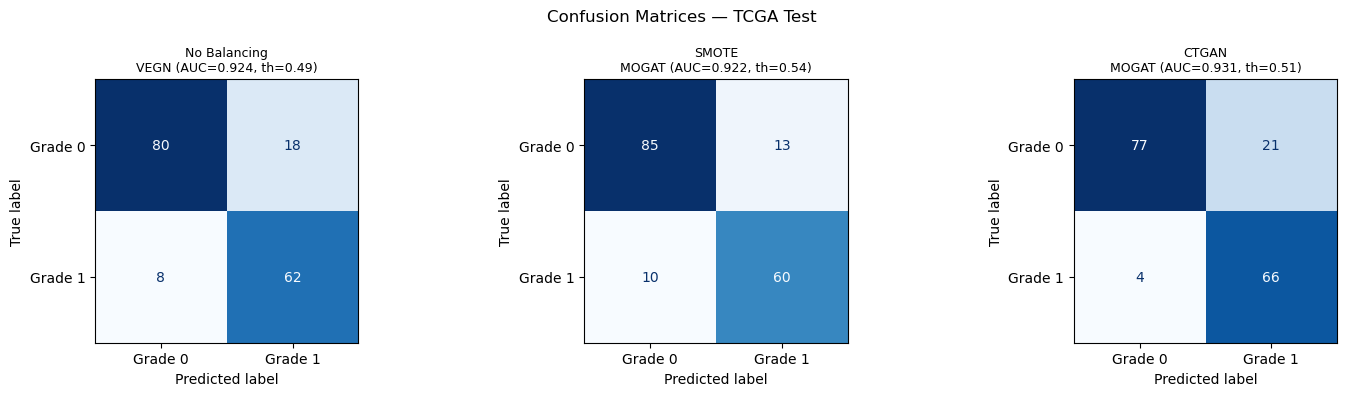

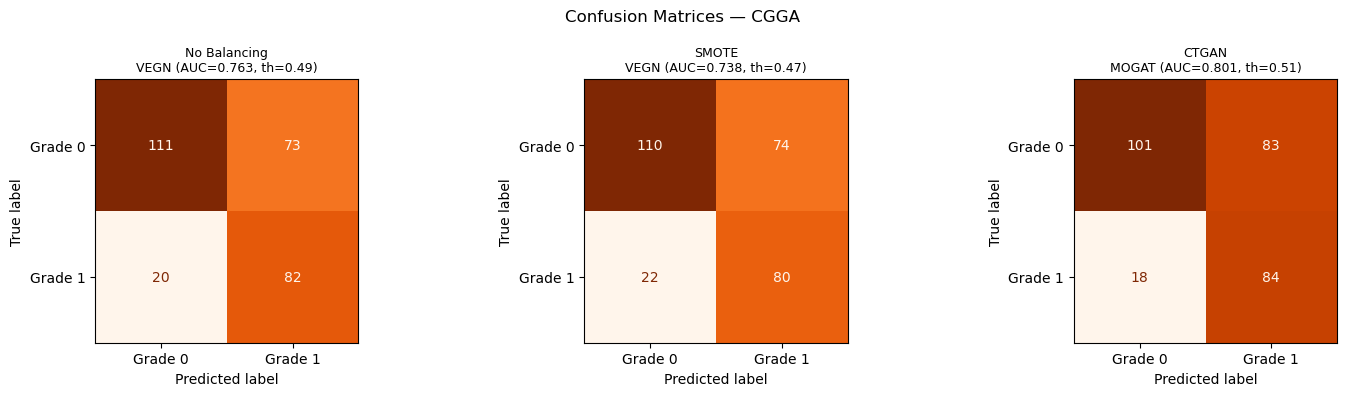

In [26]:
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f}, th={th:.2f})",
                           fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V8_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 23. Permutation Gene Feature Importance

In [27]:
def perm_importance(model, ref_df, threshold=0.5, n_repeats=10, seed=0):
    base_g = to_dev(construct_bipartite_heterograph(ref_df))
    model.eval()
    with torch.no_grad():
        bp = F.softmax(model(base_g), 1)[:, 1].cpu().numpy()
    try:
        base_auc = roc_auc_score(ref_df['Grade'].values, bp)
    except ValueError:
        return {g: 0.0 for g in gene_columns}, 0.0
    rng = np.random.default_rng(seed)
    out = {}
    for gene in gene_columns:
        drops = []
        for _ in range(n_repeats):
            df2 = ref_df.copy(); df2[gene] = rng.permutation(df2[gene].values)
            g2  = to_dev(construct_bipartite_heterograph(df2))
            with torch.no_grad():
                pp = F.softmax(model(g2), 1)[:, 1].cpu().numpy()
            try:
                drops.append(base_auc - roc_auc_score(ref_df['Grade'].values, pp))
            except ValueError:
                drops.append(0.0)
        out[gene] = float(np.mean(drops))
    clear_pp_cache()
    return out, base_auc

print("Computing permutation importance...")
imp_records = []
for mname, MCls, _ in MODEL_REGISTRY:
    for pipe in PIPELINES:
        model = all_models.get((mname, pipe))
        if model is None: continue
        th  = all_thresholds.get((mname, pipe), 0.5)
        imp, base = perm_importance(model, test_df, threshold=th)
        for gene, drop in imp.items():
            imp_records.append({'Model': mname, 'Pipeline': pipe,
                                 'Gene': gene, 'AUC_Drop': drop, 'Base_AUC': base})
        print(f"  {mname}/{pipe}  base={base:.4f}")
imp_df = pd.DataFrame(imp_records)
print("Done.")

Computing permutation importance...
  HeteroGATv2/No Balancing  base=0.9223
  HeteroGATv2/SMOTE  base=0.8904
  HeteroGATv2/CTGAN  base=0.9087
  MOGAT/No Balancing  base=0.9171
  MOGAT/SMOTE  base=0.9217
  MOGAT/CTGAN  base=0.9309
  HyperTMO/No Balancing  base=0.8297
  HyperTMO/SMOTE  base=0.8359
  HyperTMO/CTGAN  base=0.8257
  RGCN/No Balancing  base=0.8789
  RGCN/SMOTE  base=0.8318
  RGCN/CTGAN  base=0.8644
  VEGN/No Balancing  base=0.9239
  VEGN/SMOTE  base=0.9087
  VEGN/CTGAN  base=0.9210
  FastHGTConv/No Balancing  base=0.9034
  FastHGTConv/SMOTE  base=0.8535
  FastHGTConv/CTGAN  base=0.9079
  SGNN/No Balancing  base=0.8560
  SGNN/SMOTE  base=0.8618
  SGNN/CTGAN  base=0.8510
Done.


## 24. Feature Importance Plots

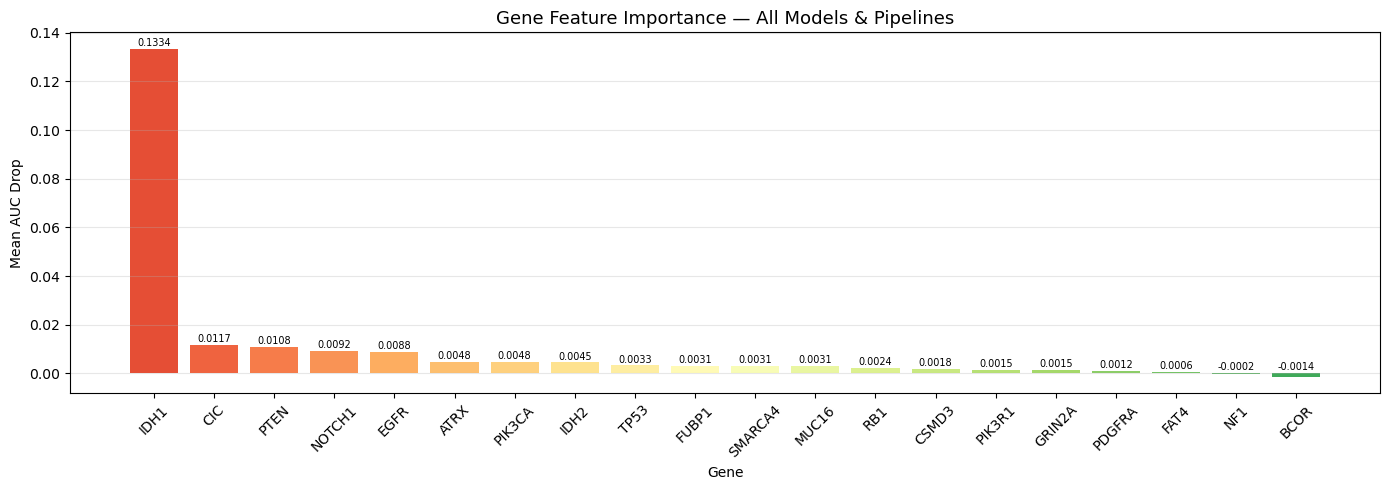

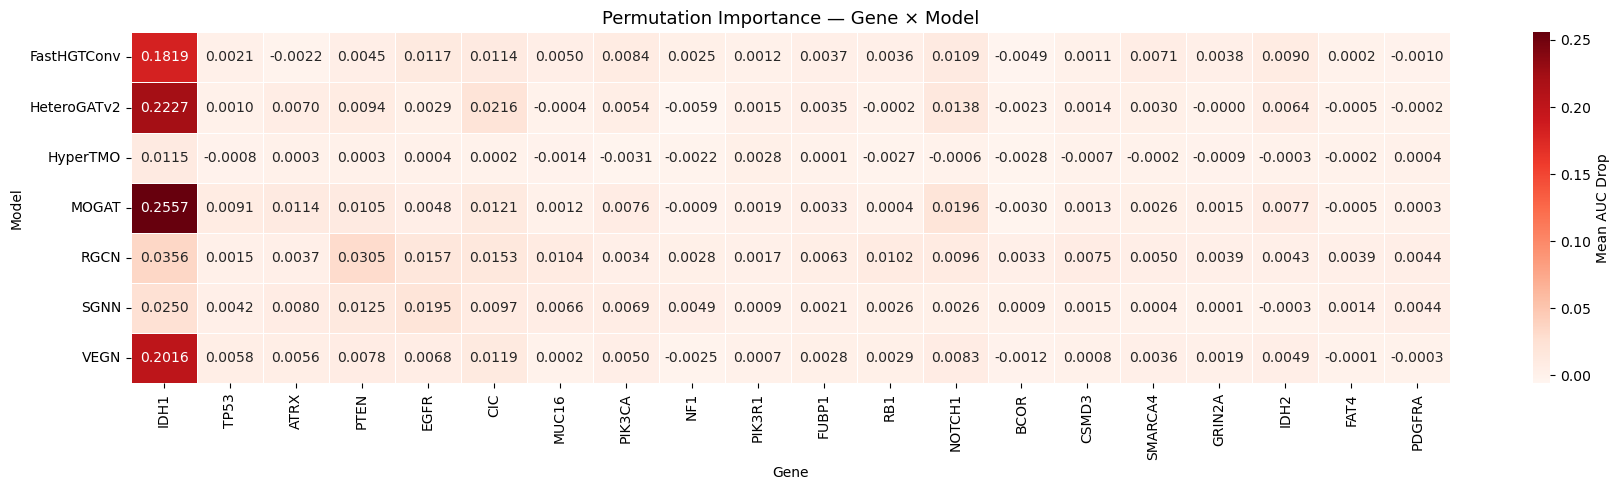


Top-5 most important genes:
Gene
IDH1      0.133413
CIC       0.011735
PTEN      0.010796
NOTCH1    0.009160
EGFR      0.008844


In [28]:
mean_imp = (imp_df.groupby('Gene')['AUC_Drop']
            .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
cvals = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(mean_imp)))
bars  = ax.bar(mean_imp.index, mean_imp.values, color=cvals)
ax.set_xlabel('Gene'); ax.set_ylabel('Mean AUC Drop')
ax.set_title('Gene Feature Importance — All Models & Pipelines', fontsize=13)
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, mean_imp.values):
    ax.text(b.get_x()+b.get_width()/2, max(v+0.0003, 0.0005),
            f'{v:.4f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('V8_feat_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap: Gene × Model
heat = (imp_df.groupby(['Model','Gene'])['AUC_Drop']
        .mean().unstack('Gene')[gene_columns])
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='Reds', linewidths=0.4,
            ax=ax, cbar_kws={'label': 'Mean AUC Drop'})
ax.set_title('Permutation Importance — Gene × Model', fontsize=13)
plt.tight_layout()
plt.savefig('V8_feat_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop-5 most important genes:")
print(mean_imp.head(5).to_string())

## 25. GAT Attention Weights

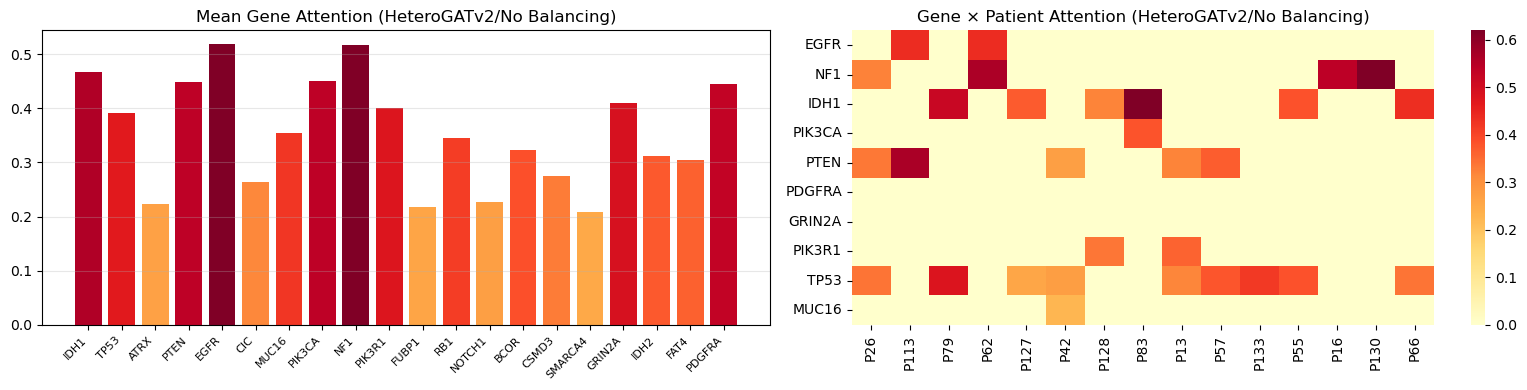

  MOGAT has no get_attn_weights — skipping.


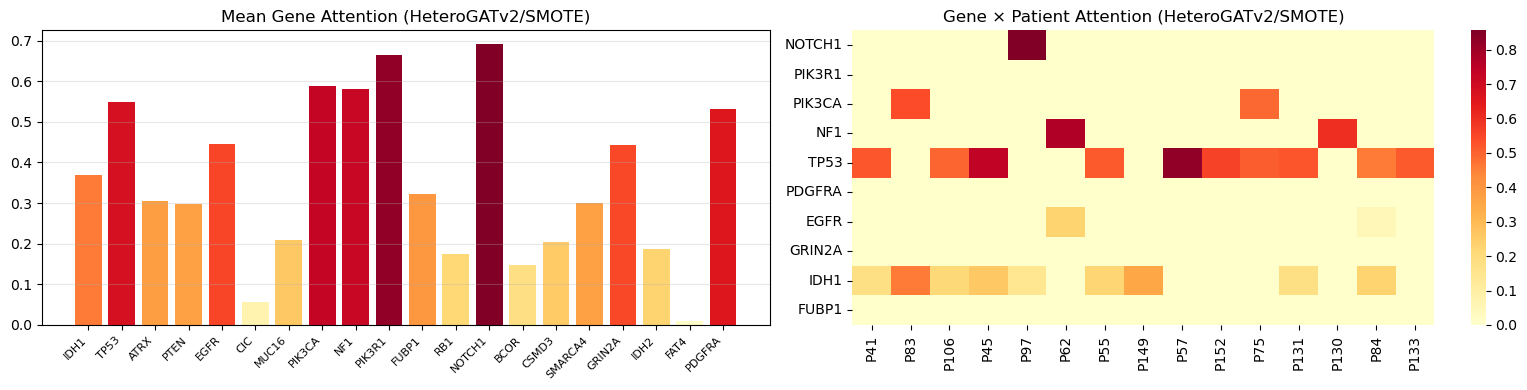

  MOGAT has no get_attn_weights — skipping.


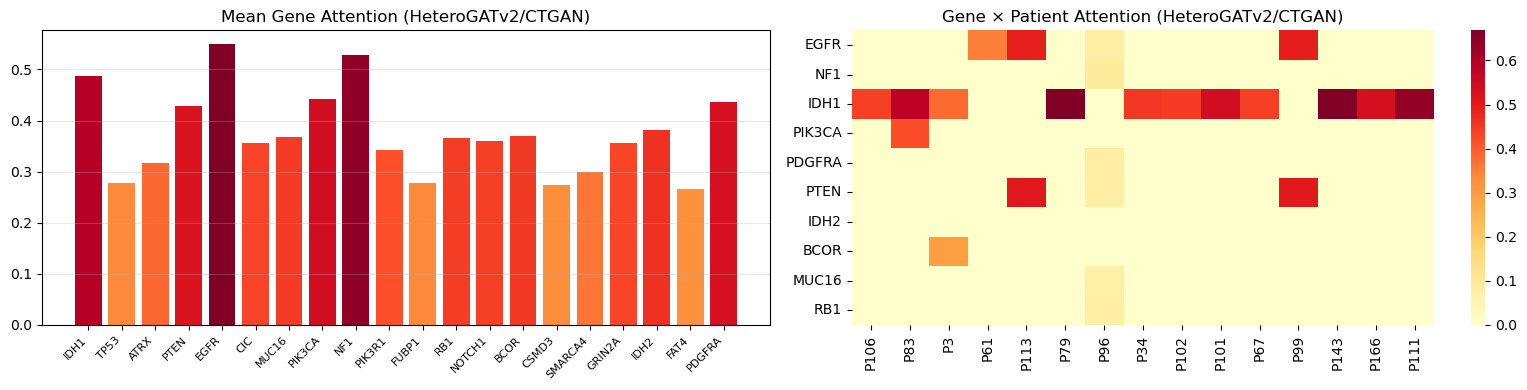

  MOGAT has no get_attn_weights — skipping.


In [29]:
def plot_gene_attention(model, graph, ref_df, title):
    model.eval()
    if not hasattr(model, 'get_attn_weights'):
        print(f"  {type(model).__name__} has no get_attn_weights — skipping."); return
    try:
        eidx, weights = model.get_attn_weights(graph)
    except Exception as e:
        print(f"  Attention extraction failed: {e}"); return
    gene_ids = eidx[0].cpu().numpy(); w = weights.cpu().numpy()
    gene_attn = np.zeros(NUM_GENES); gene_cnt = np.zeros(NUM_GENES)
    for g, wt in zip(gene_ids, w):
        if 0 <= g < NUM_GENES: gene_attn[g] += wt; gene_cnt[g] += 1
    gene_cnt = np.maximum(gene_cnt, 1); gene_attn /= gene_cnt
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    norm_a = gene_attn / (gene_attn.max() + 1e-9)
    axes[0].bar(gene_columns, gene_attn, color=plt.cm.YlOrRd(norm_a))
    axes[0].set_xticklabels(gene_columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_title(f'Mean Gene Attention ({title})'); axes[0].grid(axis='y', alpha=0.3)
    pat_ids = eidx[1].cpu().numpy(); n_pat = ref_df.shape[0]
    top_g = np.argsort(gene_attn)[::-1][:10]
    pat_wsum = np.zeros(n_pat)
    for g, p, wt in zip(gene_ids, pat_ids, w):
        if 0 <= p < n_pat: pat_wsum[p] += wt
    top_p = np.argsort(pat_wsum)[::-1][:15]
    mat = np.zeros((len(top_g), len(top_p)))
    for g_loc, g in enumerate(top_g):
        for p_loc, p in enumerate(top_p):
            mask = (gene_ids == g) & (pat_ids == p)
            if mask.any(): mat[g_loc, p_loc] = w[mask].mean()
    sns.heatmap(mat, ax=axes[1], cmap='YlOrRd',
                xticklabels=[f'P{p}' for p in top_p],
                yticklabels=[gene_columns[g] for g in top_g])
    axes[1].set_title(f'Gene × Patient Attention ({title})')
    plt.tight_layout()
    plt.savefig(f'V8_attn_{title.replace("/","_").replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

for pipe in PIPELINES:
    for mname in ['HeteroGATv2', 'MOGAT']:
        m = all_models.get((mname, pipe))
        if m: plot_gene_attention(m, test_graph, test_df, f"{mname}/{pipe}")

## 26. Classification Reports — Best Model Overall

In [30]:
for ds in ['TCGA Test','CGGA']:
    sub  = results_full[results_full.Dataset==ds]
    best = sub.loc[sub['auc'].idxmax()]
    th   = best['threshold']
    preds  = (best['probs'] >= th).astype(int)
    labels = best['labels']
    print(f"{'='*65}")
    print(f"Best on {ds}: {best['Model']} / {best['Pipeline']}")
    print(f"AUC={best['auc']:.4f}  Threshold={th:.3f}")
    print(classification_report(labels, preds, target_names=['Grade 0','Grade 1']))

Best on TCGA Test: MOGAT / CTGAN
AUC=0.9309  Threshold=0.514
              precision    recall  f1-score   support

     Grade 0       0.95      0.79      0.86        98
     Grade 1       0.76      0.94      0.84        70

    accuracy                           0.85       168
   macro avg       0.85      0.86      0.85       168
weighted avg       0.87      0.85      0.85       168

Best on CGGA: MOGAT / CTGAN
AUC=0.8008  Threshold=0.514
              precision    recall  f1-score   support

     Grade 0       0.85      0.55      0.67       184
     Grade 1       0.50      0.82      0.62       102

    accuracy                           0.65       286
   macro avg       0.68      0.69      0.65       286
weighted avg       0.73      0.65      0.65       286



## 27. Save Results

In [ ]:
# import os
# os.makedirs('saved_models_v8', exist_ok=True)
# for (mname, pipe), model in all_models.items():
#     fn = f"saved_models_v8/{mname}_{pipe.replace(' ','_')}.pth"
#     torch.save(model.state_dict(), fn)

# results_df.to_csv('V8_results_final.csv', index=False)
# cv_all.to_csv('V8_cv_results.csv', index=False)
# imp_df.to_csv('V8_feature_importance.csv', index=False)
# pd.DataFrame([{'Model':mn,'Pipeline':pp,'Threshold':th}
#                for (mn,pp),th in all_thresholds.items()]).to_csv('V8_thresholds.csv',index=False)

# print("Saved: V8_results_final.csv, V8_cv_results.csv, V8_feature_importance.csv, V8_thresholds.csv")
# print()
# print("Final AUC Summary:")
# print(results_df.pivot_table(index='Model',columns=['Pipeline','Dataset'],
#                               values='AUC',aggfunc='first').round(4).to_string())